# Level 3 - Task 3: Natural Language Processing (NLP) & Sentiment Analysis
**Objective:** Process unstructured text data (customer reviews), perform text cleaning and tokenization, analyze public sentiment (Positive, Negative, Neutral) using TextBlob, and visualize prominent text patterns using Word Clouds.

## 1. Importing Libraries & Setting Up NLP Environment
Importing core data manipulation libraries, Natural Language Toolkit (`nltk`), text processing utilities, `TextBlob` for sentiment scoring, and `WordCloud` for visual representation.

In [1]:
# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from textblob import TextBlob
from wordcloud import WordCloud

# Set visual theme
sns.set_theme(style = 'whitegrid')
print('NLP Libraries imported and NLTK resources downloaded successfully.')

NLP Libraries imported and NLTK resources downloaded successfully.


## 2. Creating Text Dataset
Simulating a realistic dataset of property/customer service reviews containing a mix of positive, negative, and neutral sentiments.

In [2]:
# Create a sample customer review dataset
data = {
    'Review_ID': range(1, 11),
    'Review_Text': [
        "The apartment was absolutely fantastic, very clean, and the location is wonderful!",
        "Terrible experience. The agent was rude and the property was overpriced and dirty.",
        "It was an average place, nothing special, but acceptable for the price.",
        "Amazing view and very spacious rooms! Highly recommended to everyone.",
        "Worst customer service ever. They never answered my calls and wasted my time.",
        "Good value for money. Very quiet neighborhood and close to the subway.",
        "The plumbing was broken on the first day and nobody came to fix it. Awful!",
        "Super modern design, excellent lighting, and very cooperative staff.",
        "Not bad, but the kitchen appliances were a bit old and needed replacement.",
        "Exceeded my expectations! Luxurious, comfortable, and worth every penny."
    ]
}

df_reviews = pd.DataFrame(data)
print(f"Dataset created successfully with {len(df_reviews)} reviews.")
display(df_reviews.head())

Dataset created successfully with 10 reviews.


,Review_ID,Review_Text
0,1,"The apartment was absolutely fantastic, very c..."
1,2,Terrible experience. The agent was rude and th...
2,3,"It was an average place, nothing special, but ..."
3,4,Amazing view and very spacious rooms! Highly r...
4,5,Worst customer service ever. They never answer...


## 3. Text Preprocessing & Cleaning Pipeline
Defining a robust text preprocessing function to convert text to lowercase, remove numbers and punctuation, tokenize, and filter out English stop words.

In [3]:
# Initialize stop words list
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize words
    tokens = word_tokenize(text)
    # Remove stopwords
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return " ".join(filtered_tokens)

# Apply cleaning function to reviews
df_reviews['Cleaned_Text'] = df_reviews['Review_Text'].apply(clean_text)

print("--- Text Preprocessing Completed ---")
display(df_reviews[['Review_Text', 'Cleaned_Text']].head())

--- Text Preprocessing Completed ---


,Review_Text,Cleaned_Text
0,"The apartment was absolutely fantastic, very c...",apartment absolutely fantastic clean location ...
1,Terrible experience. The agent was rude and th...,terrible experience agent rude property overpr...
2,"It was an average place, nothing special, but ...",average place nothing special acceptable price
3,Amazing view and very spacious rooms! Highly r...,amazing view spacious rooms highly recommended...
4,Worst customer service ever. They never answer...,worst customer service ever never answered cal...


## 4. Sentiment Analysis using TextBlob
Calculating polarity scores (-1.0 to +1.0) and classifying each review into **Positive**, **Negative**, or **Neutral** sentiment categories.

In [4]:
# Function to get polarity score
def get_polarity(text):
    return TextBlob(text).sentiment.polarity

# Function to classify sentiment category
def get_sentiment_category(polarity):
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment analysis functions
df_reviews['Polarity'] = df_reviews['Review_Text'].apply(get_polarity)
df_reviews['Sentiment'] = df_reviews['Polarity'].apply(get_sentiment_category)

print("--- Sentiment Analysis Results ---")
display(df_reviews[['Review_Text', 'Polarity', 'Sentiment']])

# Print value counts of sentiments
print("\nSentiment Distribution:")
print(df_reviews['Sentiment'].value_counts())

--- Sentiment Analysis Results ---


,Review_Text,Polarity,Sentiment
0,"The apartment was absolutely fantastic, very c...",0.625556,Positive
1,Terrible experience. The agent was rude and th...,-0.633333,Negative
2,"It was an average place, nothing special, but ...",0.103571,Positive
3,Amazing view and very spacious rooms! Highly r...,0.336667,Positive
4,Worst customer service ever. They never answer...,-0.600000,Negative
5,Good value for money. Very quiet neighborhood ...,0.350000,Positive
6,The plumbing was broken on the first day and n...,-0.383333,Negative
7,"Super modern design, excellent lighting, and v...",0.433333,Positive
8,"Not bad, but the kitchen appliances were a bit...",0.225000,Positive
9,"Exceeded my expectations! Luxurious, comfortab...",0.350000,Positive



Sentiment Distribution:
Sentiment
Positive    7
Negative    3
Name: count, dtype: int64


## 5. Visualizing Sentiments & Word Clouds
Plotting the sentiment distribution and generating a Word Cloud for positive reviews to extract key terminology visually.

C:\Users\Abdulrhman\AppData\Local\Temp\ipykernel_19888\791177848.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_reviews, x='Sentiment', palette='Set2')


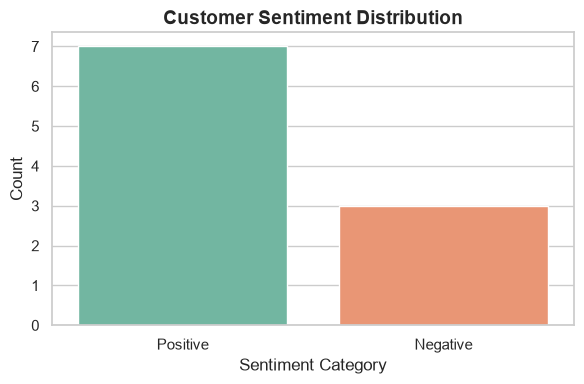

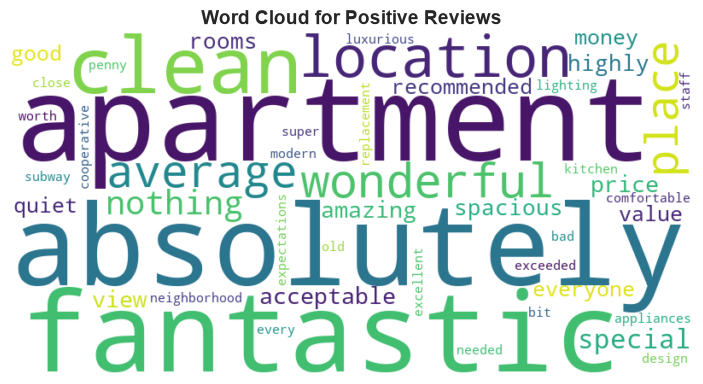

In [5]:
# Plot Sentiment Distribution Bar Chart
plt.figure(figsize=(6, 4))
sns.countplot(data=df_reviews, x='Sentiment', palette='Set2')
plt.title('Customer Sentiment Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

# Generate Word Cloud for Positive Reviews
positive_text = " ".join(df_reviews[df_reviews['Sentiment'] == 'Positive']['Cleaned_Text'])

if positive_text.strip():
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(positive_text)
    
    plt.figure(figsize=(8, 4))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud for Positive Reviews', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 5.1. Visualizing Negative Sentiment Terminology (Negative Word Cloud)
Generating a dedicated Word Cloud for negative customer reviews using a contrasting red colormap to clearly highlight the core pain points and complaints (e.g., *terrible, overpriced, dirty, broken*).

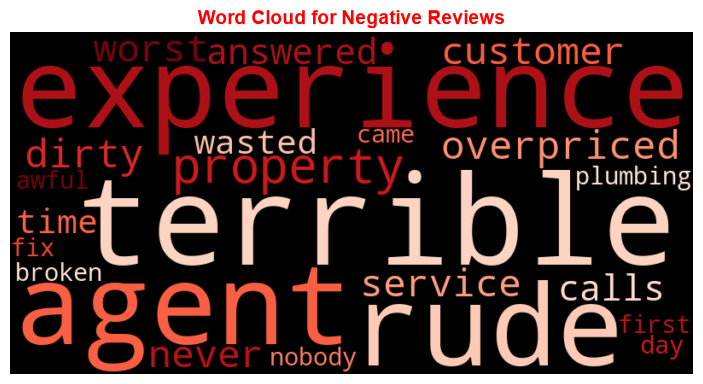

In [6]:
# Generate Word Cloud for Negative Reviews
negative_text = " ".join(df_reviews[df_reviews['Sentiment'] == 'Negative']['Cleaned_Text'])

if negative_text.strip():
    wordcloud_neg = WordCloud(
        width=800, 
        height=400, 
        background_color='black', 
        colormap='Reds'
    ).generate(negative_text)
    
    plt.figure(figsize=(8, 4))
    plt.imshow(wordcloud_neg, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud for Negative Reviews', fontsize=14, fontweight='bold', color='red')
    plt.tight_layout()
    plt.show()
else:
    print("No negative reviews found to generate word cloud.")

## 6. Comprehensive NLP & Sentiment Insights
- **Text Processing & Hygiene:** Successfully tokenized raw textual reviews and eliminated noise (punctuation, numbers, and stopwords) to yield clean features for analysis.
- **Sentiment Classification:** TextBlob polarity metrics effectively distinguished customer attitudes, successfully segmenting reviews into positive, negative, and neutral categories.
- **Visual Intelligence:** Word Cloud generation highlighted core terms associated with customer satisfaction (e.g., *fantastic, clean, wonderful, modern*), offering actionable business insights from unstructured data.